# P1 Milestone: Model Inference
# Earthquake Building Damage Grade Prediction

---

Farhan Hamid Lubis  <br>
Hacktiv8 Data Science Fulltime RMT-052 <br>
**Milestone Phase 1 - Multiclass Classification** <br>

---

This notebook demonstrates how to use the saved model (`best_model_earthquake.pkl`) and label encoder (`label_encoder.pkl`) to predict the **damage grade** of a building based on its structural characteristics.

Two inference scenarios are covered:
1. **Single record** - predict the damage grade for one building
2. **Multiple records** - predict damage grades for a batch of buildings

---
## I. Import Libraries

In [ ]:
import pandas as pd
import pickle
import warnings
warnings.filterwarnings('ignore')

---
## II. Load Model & Label Encoder

In [5]:
# Load the trained model pipeline
with open('best_model_earthquake.pkl', 'rb') as f:
    model = pickle.load(f)

# Load the label encoder for decoding predictions back to grade labels
with open('label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

print('Model loaded  :', type(model.named_steps['classifier']).__name__)
print('Label classes :', le.classes_)

Model loaded  : RandomForestClassifier
Label classes : ['Grade 1' 'Grade 2' 'Grade 3' 'Grade 4' 'Grade 5']


---
## III. Feature Reference

The model expects the following input features. Make sure all column names and category values match exactly.

| Feature | Type | Example Values |
|---|---|---|
| `count_floors_pre_eq` | int | 1, 2, 3 |
| `age_building` | int | 10, 25, 50 |
| `plinth_area_sq_ft` | int | 200, 450, 800 |
| `height_ft_pre_eq` | float | 8.0, 12.0, 20.0 |
| `land_surface_condition` | str | `'Flat'`, `'Moderate slope'`, `'Steep slope'` |
| `foundation_type` | str | `'Mud mortar-Stone/Brick'`, `'Cement-Stone/Brick'`, `'RC'`, `'Bamboo/Timber'`, `'Other'` |
| `roof_type` | str | `'Bamboo/Timber-Light roof'`, `'Bamboo/Timber-Heavy roof'`, `'RCC/RB/RBC'` |
| `ground_floor_type` | str | `'Mud'`, `'Brick/Stone'`, `'RC'`, `'Timber'`, `'Other'` |
| `other_floor_type` | str | `'Not applicable'`, `'TImber/Bamboo-Mud'`, `'Timber-Planck'`, `'RCC/RB/RBC'` |
| `position` | str | `'Not attached'`, `'Attached-1 side'`, `'Attached-2 side'`, `'Attached-3 side'` |
| `plan_configuration` | str | `'Rectangular'`, `'L-shape'`, `'T-shape'`, `'E-shape'`, `'U-shape'`, `'H-shape'`, `'Multi-projected'`, `'Others'`, `'Square'`, `'Building with Central Courtyard'` |
| `has_superstructure_adobe_mud` | int | 0 or 1 |
| `has_superstructure_mud_mortar_stone` | int | 0 or 1 |
| `has_superstructure_stone_flag` | int | 0 or 1 |
| `has_superstructure_cement_mortar_stone` | int | 0 or 1 |
| `has_superstructure_mud_mortar_brick` | int | 0 or 1 |
| `has_superstructure_cement_mortar_brick` | int | 0 or 1 |
| `has_superstructure_timber` | int | 0 or 1 |
| `has_superstructure_bamboo` | int | 0 or 1 |
| `has_superstructure_rc_non_engineered` | int | 0 or 1 |
| `has_superstructure_rc_engineered` | int | 0 or 1 |
| `has_superstructure_other` | int | 0 or 1 |

---
## IV. Single Record Inference

Predicting the damage grade for a single building.
This simulates a scenario where a field officer inputs the structural characteristics of one building.

In [13]:
# Define a single building record
single_record = {
    'count_floors_pre_eq':              2,
    'age_building':                     30,
    'plinth_area_sq_ft':                400,
    'height_ft_pre_eq':                 12.0,
    'land_surface_condition':           'Moderate slope',
    'foundation_type':                  'Mud mortar-Stone/Brick',
    'roof_type':                        'Bamboo/Timber-Light roof',
    'ground_floor_type':                'Mud',
    'other_floor_type':                 'TImber/Bamboo-Mud',
    'position':                         'Not attached',
    'plan_configuration':               'Rectangular',
    'has_superstructure_adobe_mud':              0,
    'has_superstructure_mud_mortar_stone':       1,
    'has_superstructure_stone_flag':             0,
    'has_superstructure_cement_mortar_stone':    0,
    'has_superstructure_mud_mortar_brick':       0,
    'has_superstructure_cement_mortar_brick':    0,
    'has_superstructure_timber':                 1,
    'has_superstructure_bamboo':                 0,
    'has_superstructure_rc_non_engineered':      0,
    'has_superstructure_rc_engineered':          0,
    'has_superstructure_other':                  0,
}

# Convert to DataFrame (model expects tabular input)
df_single = pd.DataFrame([single_record])

# Run prediction
pred_encoded = model.predict(df_single)
pred_label   = le.inverse_transform(pred_encoded)

print('Input Building Summary:')
print(f'  Age            : {single_record["age_building"]} years')
print(f'  Floors         : {single_record["count_floors_pre_eq"]}')
print(f'  Foundation     : {single_record["foundation_type"]}')
print(f'  Superstructure : Mud mortar stone + Timber')
print()
print(f'Predicted Damage Grade : {pred_label[0]}')

Input Building Summary:
  Age            : 30 years
  Floors         : 2
  Foundation     : Mud mortar-Stone/Brick
  Superstructure : Mud mortar stone + Timber

Predicted Damage Grade : Grade 4


In [7]:
# Get prediction probabilities for each damage grade
pred_proba = model.predict_proba(df_single)[0]
proba_df = pd.DataFrame({
    'Damage Grade': le.classes_,
    'Probability':  pred_proba
}).sort_values('Probability', ascending=False)

print('Prediction Probabilities:')
print(proba_df.to_string(index=False))

Prediction Probabilities:
Damage Grade  Probability
     Grade 4     0.369493
     Grade 5     0.266039
     Grade 3     0.199746
     Grade 2     0.097089
     Grade 1     0.067633


---
## V. Multiple Records Inference

Predicting damage grades for a batch of buildings.
This simulates a post-disaster scenario where multiple buildings need to be assessed rapidly.

Three contrasting building profiles are used:
- **Building A**: Old traditional construction (high damage expected)
- **Building B**: Modern RC engineered construction (low damage expected)
- **Building C**: Mid-age mixed construction (moderate damage expected)

In [8]:
# Define multiple building records
multi_records = [
    {   # Building A: Old traditional — high damage risk
        'count_floors_pre_eq':              1,
        'age_building':                     80,
        'plinth_area_sq_ft':                250,
        'height_ft_pre_eq':                 8.0,
        'land_surface_condition':           'Steep slope',
        'foundation_type':                  'Mud mortar-Stone/Brick',
        'roof_type':                        'Bamboo/Timber-Heavy roof',
        'ground_floor_type':                'Mud',
        'other_floor_type':                 'Not applicable',
        'position':                         'Attached-2 side',
        'plan_configuration':               'Rectangular',
        'has_superstructure_adobe_mud':              1,
        'has_superstructure_mud_mortar_stone':       1,
        'has_superstructure_stone_flag':             0,
        'has_superstructure_cement_mortar_stone':    0,
        'has_superstructure_mud_mortar_brick':       0,
        'has_superstructure_cement_mortar_brick':    0,
        'has_superstructure_timber':                 0,
        'has_superstructure_bamboo':                 0,
        'has_superstructure_rc_non_engineered':      0,
        'has_superstructure_rc_engineered':          0,
        'has_superstructure_other':                  0,
    },
    {   # Building B: Modern RC engineered — low damage risk
        'count_floors_pre_eq':              3,
        'age_building':                     5,
        'plinth_area_sq_ft':                900,
        'height_ft_pre_eq':                 24.0,
        'land_surface_condition':           'Flat',
        'foundation_type':                  'RC',
        'roof_type':                        'RCC/RB/RBC',
        'ground_floor_type':                'RC',
        'other_floor_type':                 'RCC/RB/RBC',
        'position':                         'Not attached',
        'plan_configuration':               'Rectangular',
        'has_superstructure_adobe_mud':              0,
        'has_superstructure_mud_mortar_stone':       0,
        'has_superstructure_stone_flag':             0,
        'has_superstructure_cement_mortar_stone':    0,
        'has_superstructure_mud_mortar_brick':       0,
        'has_superstructure_cement_mortar_brick':    0,
        'has_superstructure_timber':                 0,
        'has_superstructure_bamboo':                 0,
        'has_superstructure_rc_non_engineered':      0,
        'has_superstructure_rc_engineered':          1,
        'has_superstructure_other':                  0,
    },
    {   # Building C: Mid-age mixed construction — moderate risk
        'count_floors_pre_eq':              2,
        'age_building':                     25,
        'plinth_area_sq_ft':                500,
        'height_ft_pre_eq':                 14.0,
        'land_surface_condition':           'Moderate slope',
        'foundation_type':                  'Cement-Stone/Brick',
        'roof_type':                        'Bamboo/Timber-Light roof',
        'ground_floor_type':                'Brick/Stone',
        'other_floor_type':                 'Timber-Planck',
        'position':                         'Attached-1 side',
        'plan_configuration':               'Rectangular',
        'has_superstructure_adobe_mud':              0,
        'has_superstructure_mud_mortar_stone':       0,
        'has_superstructure_stone_flag':             0,
        'has_superstructure_cement_mortar_stone':    0,
        'has_superstructure_mud_mortar_brick':       0,
        'has_superstructure_cement_mortar_brick':    1,
        'has_superstructure_timber':                 1,
        'has_superstructure_bamboo':                 0,
        'has_superstructure_rc_non_engineered':      0,
        'has_superstructure_rc_engineered':          0,
        'has_superstructure_other':                  0,
    }
]

df_multi = pd.DataFrame(multi_records)
print(f'Input shape: {df_multi.shape}')
df_multi

Input shape: (3, 22)


,count_floors_pre_eq,age_building,plinth_area_sq_ft,height_ft_pre_eq,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,...,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other
0,1,80,250,8.0,Steep slope,Mud mortar-Stone/Brick,Bamboo/Timber-Heavy roof,Mud,Not applicable,Attached-2 side,...,1,0,0,0,0,0,0,0,0,0
1,3,5,900,24.0,Flat,RC,RCC/RB/RBC,RC,RCC/RB/RBC,Not attached,...,0,0,0,0,0,0,0,0,1,0
2,2,25,500,14.0,Moderate slope,Cement-Stone/Brick,Bamboo/Timber-Light roof,Brick/Stone,Timber-Planck,Attached-1 side,...,0,0,0,0,1,1,0,0,0,0


In [15]:
# Run batch prediction
pred_encoded_multi = model.predict(df_multi)
pred_labels_multi  = le.inverse_transform(pred_encoded_multi)

# Get probabilities for all records
pred_proba_multi = model.predict_proba(df_multi)

# Build results DataFrame
results = pd.DataFrame({
    'Building':          ['Building A (Old Traditional)', 'Building B (Modern RC)', 'Building C (Mid-age Mixed)'],
    'Age':               [r['age_building'] for r in multi_records],
    'Foundation':        [r['foundation_type'] for r in multi_records],
    'Predicted Grade':   pred_labels_multi,
})

# Append probability columns
proba_cols = pd.DataFrame(pred_proba_multi, columns=[f'P({c})' for c in le.classes_])
results = pd.concat([results, proba_cols.round(3)], axis=1)

print('Batch Prediction Results:\n')
results

Batch Prediction Results:



,Building,Age,Foundation,Predicted Grade,P(Grade 1),P(Grade 2),P(Grade 3),P(Grade 4),P(Grade 5)
0,Building A (Old Traditional),80,Mud mortar-Stone/Brick,Grade 5,0.082,0.045,0.075,0.139,0.658
1,Building B (Modern RC),5,RC,Grade 1,0.728,0.195,0.077,0.000,0.000
2,Building C (Mid-age Mixed),25,Cement-Stone/Brick,Grade 2,0.224,0.288,0.185,0.199,0.104


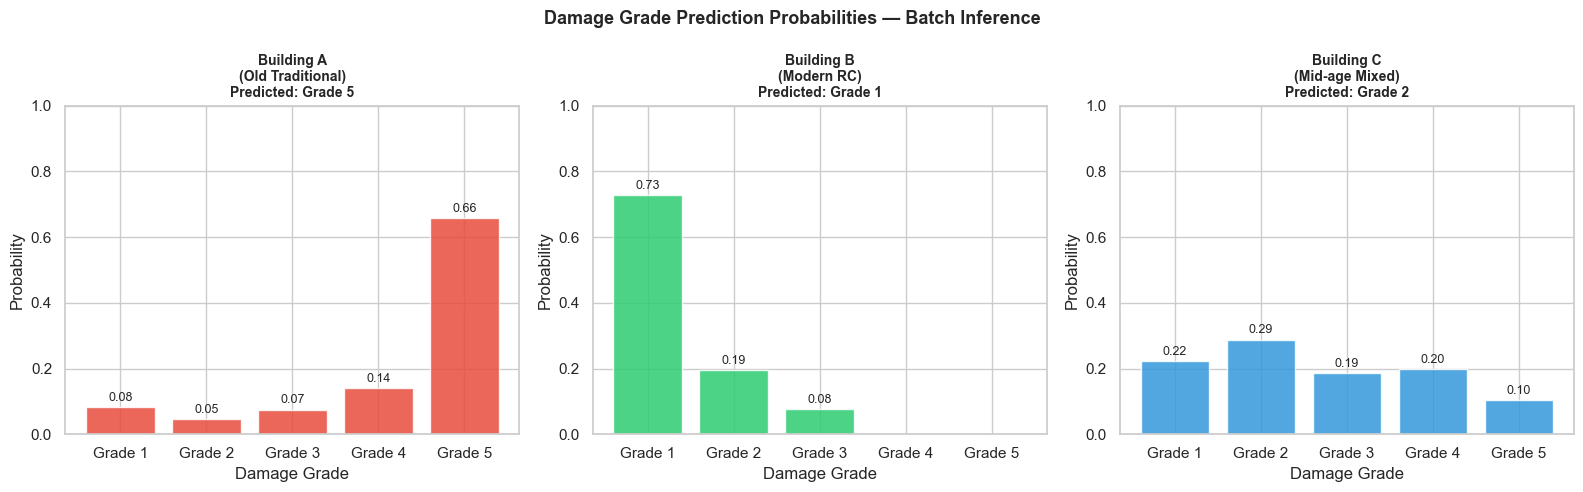

In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Set2')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

building_labels = ['Building A\n(Old Traditional)', 'Building B\n(Modern RC)', 'Building C\n(Mid-age Mixed)']
colors_per_building = ['#e74c3c', '#2ecc71', '#3498db']

for idx, (ax, label, color) in enumerate(zip(axes, building_labels, colors_per_building)):
    probs = pred_proba_multi[idx]
    bars = ax.bar(le.classes_, probs, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'{label}\nPredicted: {pred_labels_multi[idx]}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Damage Grade')
    ax.set_ylabel('Probability')
    ax.set_ylim(0, 1)
    for bar, prob in zip(bars, probs):
        if prob > 0.02:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{prob:.2f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Damage Grade Prediction Probabilities — Batch Inference', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## VI. Notes

- The model pipeline (`best_model_earthquake.pkl`) includes all preprocessing steps (imputation, scaling, encoding), so raw input data can be passed directly without manual preprocessing.
- `label_encoder.pkl` is required to convert the model's integer output back to human-readable damage grade labels.
- Input feature names and categorical values must match exactly what the model was trained on. Refer to the Feature Reference table in Section III.
- For production use, input validation should be added to catch unseen category values or missing fields before passing data to the model.